In [ ]:
# For first time setup:

!git clone https://github.com/google/deluca 
%cd deluca

!git checkout improved-api


!pip install -e .


/Users/rsalik/Documents/Code/Google/deluca


/Users/rsalik/.pyenv/versions/3.13.1/lib/python3.13/pty.py:95: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


Obtaining file:///Users/rsalik/Documents/Code/Google/deluca
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for deluca (pyproject.toml) ... done
  Created wheel for deluca: filename=deluca-0.0.17-0.editable-py3-none-any.whl size=8167 sha256=c5475eecb5506bc057dbb4aa431be2215ff411d3779188271c9856347e85d33d
  Stored in directory: /private/var/folders/zd/pxlq94zd389bp96dgw56b0900000gn/T/pip-ephem-wheel-cache-ycn9glmb/wheels/6e/ce/1b/6c4512f4b38168466dee61d1ca5f9765d0c15735eb0d3491c2
Successfully built deluca
^C
Traceback (most recent call last):
  File "/Users/rsalik/.pyenv/versions/3.13.1/envs/deluca-env/bin/pip", line 8, in <module>
    sys.exit(main())
             ~~~~^^
  File "/Users/rsalik/.pyenv/versions/3.13.1/envs/deluca-env/lib/python3.13/site-packages/pip/_internal/cli/main.py", line 79, in main
    r

In [ ]:
!pip install -q ipympl
# Must restart kernel after this

/Users/rsalik/.pyenv/versions/3.13.1/lib/python3.13/pty.py:95: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


In [1]:
%matplotlib widget

In [1]:
%load_ext autoreload
%autoreload 1

import jax

from deluca.agents.new.linear import LinearAgent
from deluca.filters.spectral import SpectralFilter
from deluca.memory import MemorySettings
from deluca.agents.new.linear import DefaultSettings as LinearAgentDefaultSettings
from deluca.utils.printing import Task

# JAX random key
rng = jax.random.key(0)

### **Creating an Environment**

In [2]:
%autoreload 1

import jax

from deluca.envs._brax import BraxEnv

# Creating the environment
rng, env_rng = jax.random.split(rng)
env = BraxEnv(env_rng, "inverted_double_pendulum")

/Users/rsalik/.pyenv/versions/3.13.1/envs/deluca-env/lib/python3.13/site-packages/brax/io/mjcf.py:480: UserWarning: Brax System, piplines and environments are not actively being maintained. Please see MJX for a well maintained JAX-based physics engine: https://github.com/google-deepmind/mujoco/tree/main/mjx. For a host of environments that use MJX, see: https://github.com/google-deepmind/mujoco_playground.
  warnings.warn(


#### **Defining a loss function**

In [3]:
from jax import Array
from typing import Any
import jax.numpy as jnp


from jax import Array
from typing import Any
import jax.numpy as jnp


def loss_fn(action: Array, next_state: Any, next_obs: Array) -> Array:
    """Inverted Double Pendulum Loss

    Observation Space
    - 0: Position of Cart on Linear Surface
    - 1: Vertical Angle of Pole on the Cart (goal: keep straight up)
    - 2: Linear Velocity of the Cart (goal: minimize)
    - 3: Angular Velocity of the pole on the cart (goal: minimize)"""

    penalties = jnp.array([0, 10, 0.1, 0.7])
    return jnp.sum(jnp.square(next_obs) * penalties) + next_state.done * 50

### **Setting up an Agent**
1. Create a memory -- lets the agent store the history of observations and actions, and can add Spectral Filtering
2. Define the agent's settings, or use default
3. Create the agent itself

In [8]:
%autoreload 1

# 1. Create a memory
filter = SpectralFilter(env.observation_size, env.action_size)
memory_settings = MemorySettings.from_env(env, 20, filter)

# 2. Define the agent's settings, or use default
settings = LinearAgentDefaultSettings.replace(loss_fn=loss_fn) # type: ignore

# 3. Create the agent itself
rng, agent_rng = jax.random.split(rng)
agent = LinearAgent(memory_settings, settings, rng=agent_rng)

#### **Create a Training Loop**

In [ ]:
from deluca.utils.printing import progress


losses = []

# Slowly build up the agent's knowledge, first with one step, then working up to multiple steps.
curriculum = [
    (1, 2, 100), # First train for 100 iterations with 1 step averaged over 2 episodes
    (2, 2, 500), # Then train for 500 iterations with 2 steps averaged over 2 episodes
    (3, 3, 500), # ...
    (4, 3, 500),
    (5, 3, 500),
    (6, 3, 500),
    (7, 3, 300),
    (8, 3, 300),
    (10, 5, 1000),
    (15, 7, 5000),
    (30, 7, 5000),
    (50, 7, 15000)
]

for T, N, iters in progress(curriculum, f"Training Agent according to curriculum"):
    rng, train_key = jax.random.split(rng)
    for irng in progress(jax.random.split(train_key, iters), f"Training with {N} episodes of length {T}"):
        losses_out = agent.train(env, N, T, irng)
        losses.append(losses_out)


✔ Training Agent according to curriculum [██████████████████████████████] [Completed 1]


#### **Plotting Results**

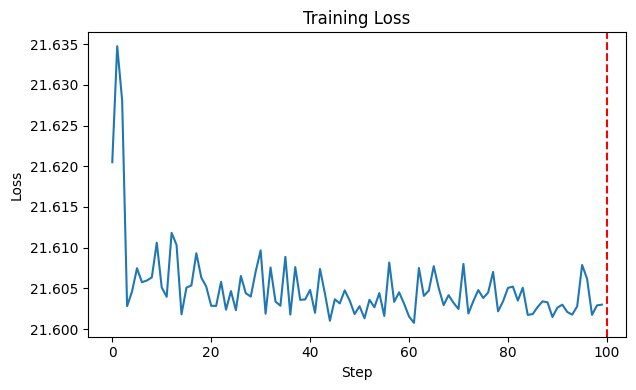

In [10]:
import matplotlib.pyplot as plt


plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(losses)

# Plot vertical lines at the end of each training plan
cum_iters = 0
for T, N, iters in curriculum:
    cum_iters += iters
    plt.axvline(x=cum_iters, color='r', linestyle='--')


plt.title('Training Loss')
plt.xlabel('Step')
plt.ylabel('Loss')

plt.tight_layout()
plt.show()


#### **Rendering the trajectory**


**Note:** Only Brax environments support rendering. The process for displaying the render is different in Jupyter notebooks than Python scripts.

In [ ]:
%autoreload 1

import jax

from deluca.memory.memory import Memory
from IPython.display import display, HTML

rng, reset_key = jax.random.split(rng)
memory = Memory(memory_settings).reset_env(env, reset_key)

states = [memory.state]
# Run the trained model for 100 steps
for rng in jax.random.split(rng, 100):
    agent_key, env_key = jax.random.split(rng)
    action = agent(memory.get_history(), rng)
    memory = memory.act(env, action, env_key)
    states.append(memory.state)

with open("out.html", "w") as f:
    display(HTML(env.render(states)))
